In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# K-means

In [2]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data = load_iris()
x = data.data[:,[0,1]] #sepal length and width

x_scaled = np.random.rand(1000,2)

scaler = StandardScaler()
#x_scaled = scaler.fit_transform(x)

kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(x_scaled)

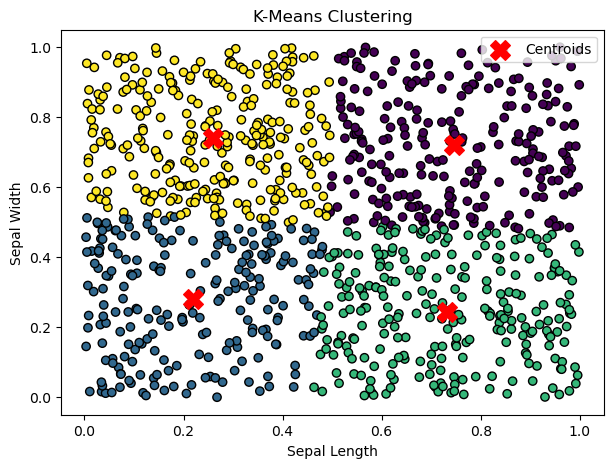

In [3]:
plt.figure(figsize=(7, 5))

plt.scatter(
    x_scaled[:, 0],
    x_scaled[:, 1],
    c=labels,
    edgecolors='k'
)

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200,
    c='red',
    marker='X',
    label='Centroids'
)

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("K-Means Clustering")
plt.legend()
plt.show()

### selecting value of k using elbow method
WCSS (Within-Cluster Sum of Squares) is the total squared distance between each data point and its assigned cluster centroid  

Lower WCSS : tighter, better clusters

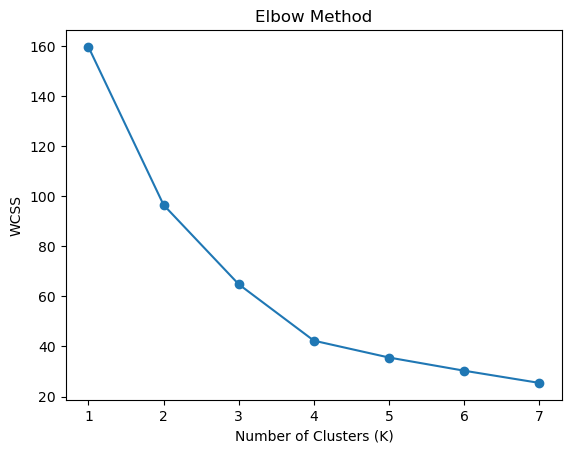

In [4]:
wcss = []

for k in range(1, 8):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(x_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1, 8), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

### Silhouette Score
Silhouette = (b−a) / max(a,b)  
a = mean distance to same-cluster points  
b = mean distance to nearest other cluster  

Range :  
+1 → very good clustering  
0 → overlapping clusters  
−1 → wrong clustering  

In [5]:
from sklearn.metrics import silhouette_score

score = silhouette_score(x_scaled, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.38554336556668556


## Hierarchical Clustering

In [19]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import dendrogram, linkage

In [20]:
#loading dataset
data = load_iris(as_frame=True)

x = data.data
feature_names = data.feature_names

print("Shape:", x.shape)
print("Features : ", feature_names)

Shape: (150, 4)
Features :  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [21]:
data.frame.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [22]:
#scaling the data
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

### Plotting Dendogram

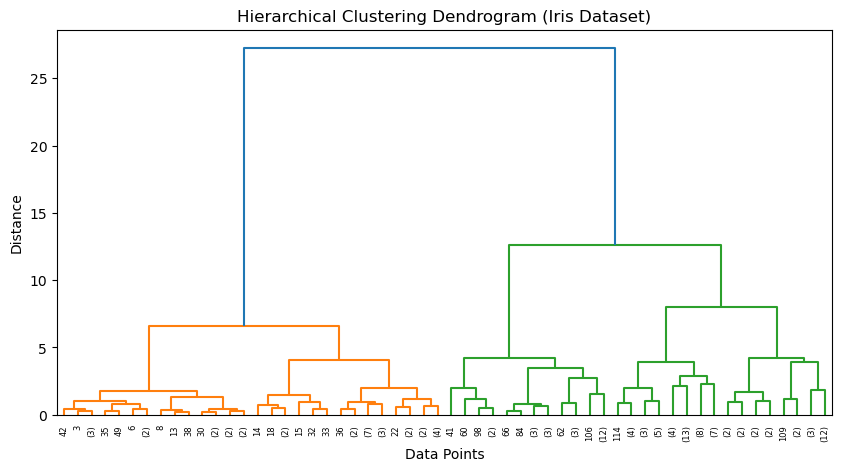

In [34]:
linked = linkage(x_scaled, method='ward')  #Minimizes variance

plt.figure(figsize=(10, 5))
dendrogram(linked,
           truncate_mode='level',
           p=5)

plt.title("Hierarchical Clustering Dendrogram (Iris Dataset)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

### Agglomerative Clustering

In [24]:
hc = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

labels = hc.fit_predict(x_scaled)

### Visualizing Clusters

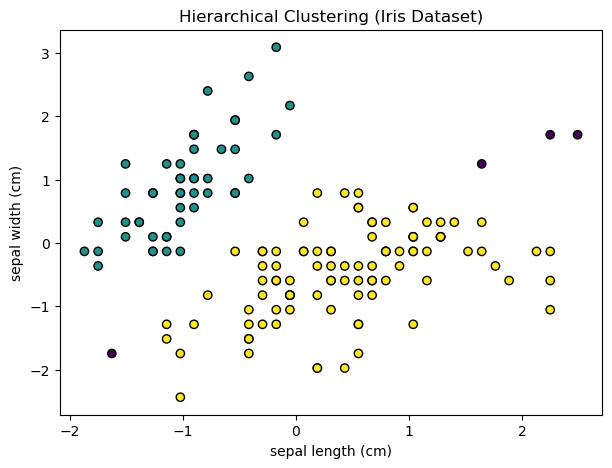

In [33]:
plt.figure(figsize=(7, 5))

plt.scatter(
    x_scaled[:, 0],
    x_scaled[:, 1],
    c=labels,
    edgecolors='k'
)

plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title("Hierarchical Clustering (Iris Dataset)")
plt.show()

## DBSCAN
Density-Based Spatial Clustering of Applications with Noise  

In [13]:
from sklearn.cluster import DBSCAN

In [27]:
data = load_iris(as_frame=True)
X = data.data
feature_names = data.feature_names

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [28]:
db = DBSCAN(eps=0.8, min_samples=5)  #eps:the maximum radius around a point within which other points are considered neighbors
labels = db.fit_predict(X_scaled)

print("Unique labels:", np.unique(labels))  # -1:noise

Unique labels: [-1  0  1]


In [29]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("Estimated number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

Estimated number of clusters: 2
Number of noise points: 4


In [30]:
if n_clusters > 1:
    score = silhouette_score(X_scaled, labels)
    print("Silhouette Score:", score)

Silhouette Score: 0.5216965052515835


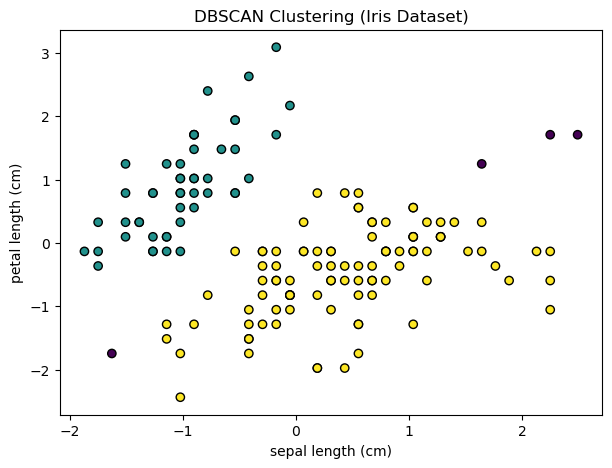

In [32]:
plt.figure(figsize=(7, 5))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels,
    edgecolors='k'
)

plt.xlabel(feature_names[0])
plt.ylabel(feature_names[2])
plt.title("DBSCAN Clustering (Iris Dataset)")
plt.show()